In [1]:
!pip install geopandas pysal libpysal esda splot

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ------------ --------------------------- 0.8/2.5 MB 4.8 MB/s eta 0:00:01
   ---------------- ----------------------- 1.0/2.5 MB 4.8 MB/s eta 0:00:01
   ---------------- ----------------------- 1.0/2.5 MB 4.8 MB/s eta 0:00:01
   --------------------------------- ------ 2.1/2.5 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 2.5 MB/s  0:00:00
   ---------------------------------------- 0.0/882.2 kB ? eta -:--:--
   ---------------------------------------- 882.2/882.2 kB 5.0 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ----

In [14]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from libpysal.weights import KNN
from esda.moran import Moran, Moran_Local
from splot.esda import plot_moran

In [27]:
# Load temperature data
temp_df = pd.read_csv("temperature_clean.csv")

# Load urban surface data (contains spatial structure)
urban_df = pd.read_csv("urban_surface.csv")

In [28]:
# Calculate mean surface temperature per neighbourhood
temp_agg = temp_df.groupby("neighbourhood_id")["surface_temp"].mean().reset_index()

temp_agg.rename(columns={"surface_temp": "mean_surface_temp"}, inplace=True)

In [29]:
# Merge with urban spatial dataset
merged = urban_df.merge(temp_agg, on="neighbourhood_id", how="inner")

In [30]:
gdf = gpd.GeoDataFrame(
    merged,
    geometry=gpd.points_from_xy(merged.longitude, merged.latitude),
    crs="EPSG:4326"
)

In [31]:
coords = list(zip(gdf.geometry.x, gdf.geometry.y))

w = KNN.from_array(coords, k=5)
w.transform = "r"   # Row-standardization

In [32]:
moran = Moran(gdf["mean_surface_temp"], w)

print("Moran’s I:", moran.I)
print("p-value:", moran.p_sim)

Moran’s I: 0.8608087761542424
p-value: 0.001


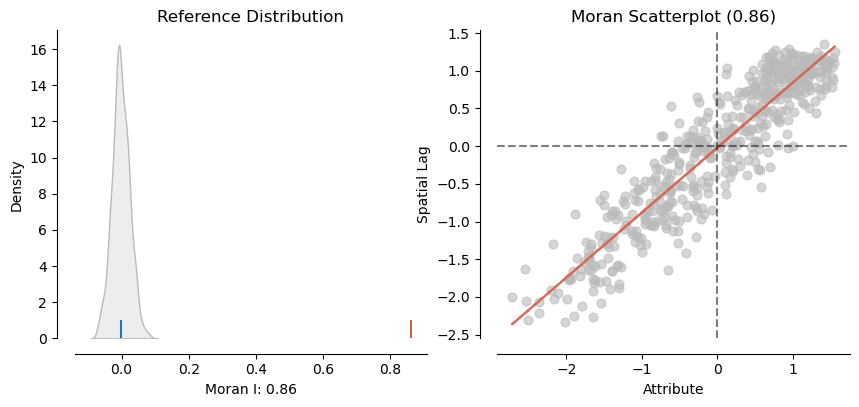

In [33]:
plot_moran(moran)
plt.show()

In [34]:
lisa = Moran_Local(gdf["mean_surface_temp"], w)

gdf["local_moran"] = lisa.Is
gdf["p_value"] = lisa.p_sim

In [35]:
significant = lisa.p_sim < 0.05

gdf["cluster"] = "Not Significant"

gdf.loc[(lisa.q == 1) & significant, "cluster"] = "High-High"
gdf.loc[(lisa.q == 2) & significant, "cluster"] = "Low-High"
gdf.loc[(lisa.q == 3) & significant, "cluster"] = "Low-Low"
gdf.loc[(lisa.q == 4) & significant, "cluster"] = "High-Low"

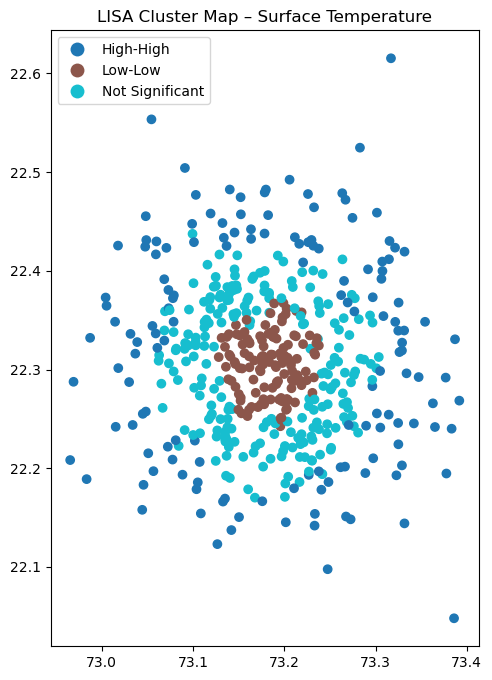

In [39]:
fig, ax = plt.subplots(figsize=(8,8))

gdf.plot(column="cluster",
         categorical=True,
         legend=True,
         figsize=(8,8),
         ax=ax)

plt.title("LISA Cluster Map – Surface Temperature")
plt.show()

In [37]:
high_high = gdf[gdf["cluster"] == "High-High"]

print("Average Asphalt in High-High Clusters:", high_high["asphalt_pct"].mean())
print("Average Tree Cover in High-High Clusters:", high_high["tree_cover_pct"].mean())
print("Average Building Density in High-High Clusters:", high_high["building_density"].mean())

Average Asphalt in High-High Clusters: 89.80597516336785
Average Tree Cover in High-High Clusters: 10.501970802135366
Average Building Density in High-High Clusters: 0.301261488369709


In [38]:
print("City-wide Asphalt Mean:", gdf["asphalt_pct"].mean())
print("City-wide Tree Cover Mean:", gdf["tree_cover_pct"].mean())
print("City-wide Density Mean:", gdf["building_density"].mean())

City-wide Asphalt Mean: 76.07389014502247
City-wide Tree Cover Mean: 28.972086164361507
City-wide Density Mean: 0.455005166143592


In [40]:
high_high = gdf[gdf["cluster"] == "High-High"]
low_low = gdf[gdf["cluster"] == "Low-Low"]

print("---- HIGH-HIGH ----")
print("Asphalt:", high_high["asphalt_pct"].mean())
print("Tree Cover:", high_high["tree_cover_pct"].mean())
print("Density:", high_high["building_density"].mean())

print("\n---- LOW-LOW ----")
print("Asphalt:", low_low["asphalt_pct"].mean())
print("Tree Cover:", low_low["tree_cover_pct"].mean())
print("Density:", low_low["building_density"].mean())

print("\n---- CITY MEAN ----")
print("Asphalt:", gdf["asphalt_pct"].mean())
print("Tree Cover:", gdf["tree_cover_pct"].mean())
print("Density:", gdf["building_density"].mean())

---- HIGH-HIGH ----
Asphalt: 89.80597516336785
Tree Cover: 10.501970802135366
Density: 0.301261488369709

---- LOW-LOW ----
Asphalt: 56.177732507251974
Tree Cover: 47.88881976749987
Density: 0.6954533000946289

---- CITY MEAN ----
Asphalt: 76.07389014502247
Tree Cover: 28.972086164361507
Density: 0.455005166143592


In [44]:
!pip install folium


   ---------------------------------------- 2/2 [folium]



In [45]:
import folium

# Center map
center = [gdf.latitude.mean(), gdf.longitude.mean()]
m = folium.Map(location=center, zoom_start=12)

# Color dictionary
color_dict = {
    "High-High": "red",
    "Low-Low": "blue",
    "High-Low": "orange",
    "Low-High": "purple",
    "Not Significant": "gray"
}

for _, row in gdf.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=4,
        color=color_dict[row["cluster"]],
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

m